In [165]:
import torch 
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm

In [166]:
data_path='./data/poem.txt'
data=pd.read_csv(data_path,header=None,names=['text'])
data['tokens']=data['text'].str.split()
#中文：data['tokens'] = data['text'].apply(lambda x: list(str(x)))

data
#batch_size=14+1

,text,tokens
0,风 吹 柳 絮 过 长 亭 人 倚 阑 干 望 远 山 <end>,"[风, 吹, 柳, 絮, 过, 长, 亭, 人, 倚, 阑, 干, 望, 远, 山, <end>]"
1,月 照 花 影 入 疏 窗 梦 随 烟 水 到 江 南 <end>,"[月, 照, 花, 影, 入, 疏, 窗, 梦, 随, 烟, 水, 到, 江, 南, <end>]"
2,春 水 初 生 绿 如 蓝 小 舟 轻 载 一 襟 寒 <end>,"[春, 水, 初, 生, 绿, 如, 蓝, 小, 舟, 轻, 载, 一, 襟, 寒, <end>]"
3,雁 声 远 去 暮 云 低 旧 梦 难 寻 旧 时 溪 <end>,"[雁, 声, 远, 去, 暮, 云, 低, 旧, 梦, 难, 寻, 旧, 时, 溪, <end>]"
4,残 灯 未 灭 夜 初 长 谁 把 离 愁 寄 远 方 <end>,"[残, 灯, 未, 灭, 夜, 初, 长, 谁, 把, 离, 愁, 寄, 远, 方, <end>]"
5,寒 烟 漠 漠 锁 空 洲 归 客 未 归 人 倚 楼 <end>,"[寒, 烟, 漠, 漠, 锁, 空, 洲, 归, 客, 未, 归, 人, 倚, 楼, <end>]"
6,小 桥 流 水 绕 人 家 晚 风 吹 落 一 庭 花 <end>,"[小, 桥, 流, 水, 绕, 人, 家, 晚, 风, 吹, 落, 一, 庭, 花, <end>]"
7,云 深 不 见 旧 时 山 梦 里 相 逢 又 一 年 <end>,"[云, 深, 不, 见, 旧, 时, 山, 梦, 里, 相, 逢, 又, 一, 年, <end>]"
8,落 花 无 语 向 黄 昏 独 倚 西 窗 忆 故 人 <end>,"[落, 花, 无, 语, 向, 黄, 昏, 独, 倚, 西, 窗, 忆, 故, 人, <end>]"
9,烟 波 千 里 送 归 舟 月 明 何 处 不 生 愁 <end>,"[烟, 波, 千, 里, 送, 归, 舟, 月, 明, 何, 处, 不, 生, 愁, <end>]"


In [167]:
#tockenizer:
all_words=[word for tokens in data['tokens'] for word in tokens]
vocab={word:idx for idx,word in enumerate(set(all_words),start=1)}
vocab_size=len(set(all_words))
print('vocabulary:',vocab)
data['tokens_ids']=data['tokens'].apply(lambda x: [vocab[word] for word in x])

data

vocabulary: {'流': 1, '细': 2, '檐': 3, '客': 4, '向': 5, '凋': 6, '生': 7, '云': 8, '堂': 9, '声': 10, '边': 11, '归': 12, '何': 13, '见': 14, '离': 15, '阑': 16, '江': 17, '犹': 18, '晚': 19, '残': 20, '帷': 21, '庭': 22, '难': 23, '上': 24, '香': 25, '新': 26, '小': 27, '星': 28, '初': 29, '千': 30, '桃': 31, '绿': 32, '帆': 33, '枕': 34, '湿': 35, '苍': 36, '青': 37, '舟': 38, '里': 39, '黄': 40, '花': 41, '入': 42, '画': 43, '方': 44, '月': 45, '春': 46, '又': 47, '洲': 48, '深': 49, '语': 50, '烟': 51, '水': 52, '在': 53, '疏': 54, '<end>': 55, '襟': 56, '落': 57, '随': 58, '明': 59, '停': 60, '玉': 61, '相': 62, '飞': 63, '处': 64, '空': 65, '未': 66, '绕': 67, '愁': 68, '孤': 69, '事': 70, '去': 71, '淡': 72, '锁': 73, '色': 74, '钟': 75, '寒': 76, '漠': 77, '时': 78, '吹': 79, '照': 80, '雁': 81, '家': 82, '独': 83, '有': 84, '溪': 85, '草': 86, '桂': 87, '忆': 88, '畔': 89, '干': 90, '楼': 91, '簟': 92, '倚': 93, '长': 94, '年': 95, '影': 96, '灭': 97, '轻': 98, '东': 99, '一': 100, '絮': 101, '谁': 102, '过': 103, '秋': 104, '望': 105, '无': 106, '寻': 107, '载': 108, '故': 109, '

,text,tokens,tokens_ids
0,风 吹 柳 絮 过 长 亭 人 倚 阑 干 望 远 山 <end>,"[风, 吹, 柳, 絮, 过, 长, 亭, 人, 倚, 阑, 干, 望, 远, 山, <end>]","[120, 79, 118, 101, 103, 94, 137, 126, 93, 16,..."
1,月 照 花 影 入 疏 窗 梦 随 烟 水 到 江 南 <end>,"[月, 照, 花, 影, 入, 疏, 窗, 梦, 随, 烟, 水, 到, 江, 南, <end>]","[45, 80, 41, 96, 42, 54, 128, 113, 58, 51, 52,..."
2,春 水 初 生 绿 如 蓝 小 舟 轻 载 一 襟 寒 <end>,"[春, 水, 初, 生, 绿, 如, 蓝, 小, 舟, 轻, 载, 一, 襟, 寒, <end>]","[46, 52, 29, 7, 32, 114, 121, 27, 38, 98, 108,..."
3,雁 声 远 去 暮 云 低 旧 梦 难 寻 旧 时 溪 <end>,"[雁, 声, 远, 去, 暮, 云, 低, 旧, 梦, 难, 寻, 旧, 时, 溪, <end>]","[81, 10, 141, 71, 142, 8, 129, 125, 113, 23, 1..."
4,残 灯 未 灭 夜 初 长 谁 把 离 愁 寄 远 方 <end>,"[残, 灯, 未, 灭, 夜, 初, 长, 谁, 把, 离, 愁, 寄, 远, 方, <end>]","[20, 111, 66, 97, 149, 29, 94, 102, 139, 15, 6..."
5,寒 烟 漠 漠 锁 空 洲 归 客 未 归 人 倚 楼 <end>,"[寒, 烟, 漠, 漠, 锁, 空, 洲, 归, 客, 未, 归, 人, 倚, 楼, <end>]","[76, 51, 77, 77, 73, 65, 48, 12, 4, 66, 12, 12..."
6,小 桥 流 水 绕 人 家 晚 风 吹 落 一 庭 花 <end>,"[小, 桥, 流, 水, 绕, 人, 家, 晚, 风, 吹, 落, 一, 庭, 花, <end>]","[27, 115, 1, 52, 67, 126, 82, 19, 120, 79, 57,..."
7,云 深 不 见 旧 时 山 梦 里 相 逢 又 一 年 <end>,"[云, 深, 不, 见, 旧, 时, 山, 梦, 里, 相, 逢, 又, 一, 年, <end>]","[8, 49, 116, 14, 125, 78, 131, 113, 39, 62, 14..."
8,落 花 无 语 向 黄 昏 独 倚 西 窗 忆 故 人 <end>,"[落, 花, 无, 语, 向, 黄, 昏, 独, 倚, 西, 窗, 忆, 故, 人, <end>]","[57, 41, 106, 50, 5, 40, 145, 83, 93, 143, 128..."
9,烟 波 千 里 送 归 舟 月 明 何 处 不 生 愁 <end>,"[烟, 波, 千, 里, 送, 归, 舟, 月, 明, 何, 处, 不, 生, 愁, <end>]","[51, 146, 30, 39, 134, 12, 38, 45, 59, 13, 64,..."


In [168]:
input_ids=np.array(data['tokens_ids'].tolist())

batch_size,_=input_ids.shape
input_ids,batch_size
#batch_size=15
#dim0=batch_size,dim1=len

(array([[120,  79, 118, 101, 103,  94, 137, 126,  93,  16,  90, 105, 141,
         131,  55],
        [ 45,  80,  41,  96,  42,  54, 128, 113,  58,  51,  52, 119,  17,
         122,  55],
        [ 46,  52,  29,   7,  32, 114, 121,  27,  38,  98, 108, 100,  56,
          76,  55],
        [ 81,  10, 141,  71, 142,   8, 129, 125, 113,  23, 107, 125,  78,
          85,  55],
        [ 20, 111,  66,  97, 149,  29,  94, 102, 139,  15,  68, 110, 141,
          44,  55],
        [ 76,  51,  77,  77,  73,  65,  48,  12,   4,  66,  12, 126,  93,
          91,  55],
        [ 27, 115,   1,  52,  67, 126,  82,  19, 120,  79,  57, 100,  22,
          41,  55],
        [  8,  49, 116,  14, 125,  78, 131, 113,  39,  62, 148,  47, 100,
          95,  55],
        [ 57,  41, 106,  50,   5,  40, 145,  83,  93, 143, 128,  88, 109,
         126,  55],
        [ 51, 146,  30,  39, 134,  12,  38,  45,  59,  13,  64, 116,   7,
          68,  55],
        [ 54, 140,  98,  76,  35,  43,   3,  46, 120, 100, 1

In [169]:
x=torch.tensor(input_ids)
x


tensor([[120,  79, 118, 101, 103,  94, 137, 126,  93,  16,  90, 105, 141, 131,
          55],
        [ 45,  80,  41,  96,  42,  54, 128, 113,  58,  51,  52, 119,  17, 122,
          55],
        [ 46,  52,  29,   7,  32, 114, 121,  27,  38,  98, 108, 100,  56,  76,
          55],
        [ 81,  10, 141,  71, 142,   8, 129, 125, 113,  23, 107, 125,  78,  85,
          55],
        [ 20, 111,  66,  97, 149,  29,  94, 102, 139,  15,  68, 110, 141,  44,
          55],
        [ 76,  51,  77,  77,  73,  65,  48,  12,   4,  66,  12, 126,  93,  91,
          55],
        [ 27, 115,   1,  52,  67, 126,  82,  19, 120,  79,  57, 100,  22,  41,
          55],
        [  8,  49, 116,  14, 125,  78, 131, 113,  39,  62, 148,  47, 100,  95,
          55],
        [ 57,  41, 106,  50,   5,  40, 145,  83,  93, 143, 128,  88, 109, 126,
          55],
        [ 51, 146,  30,  39, 134,  12,  38,  45,  59,  13,  64, 116,   7,  68,
          55],
        [ 54, 140,  98,  76,  35,  43,   3,  46, 120, 100, 1

### 维度问题
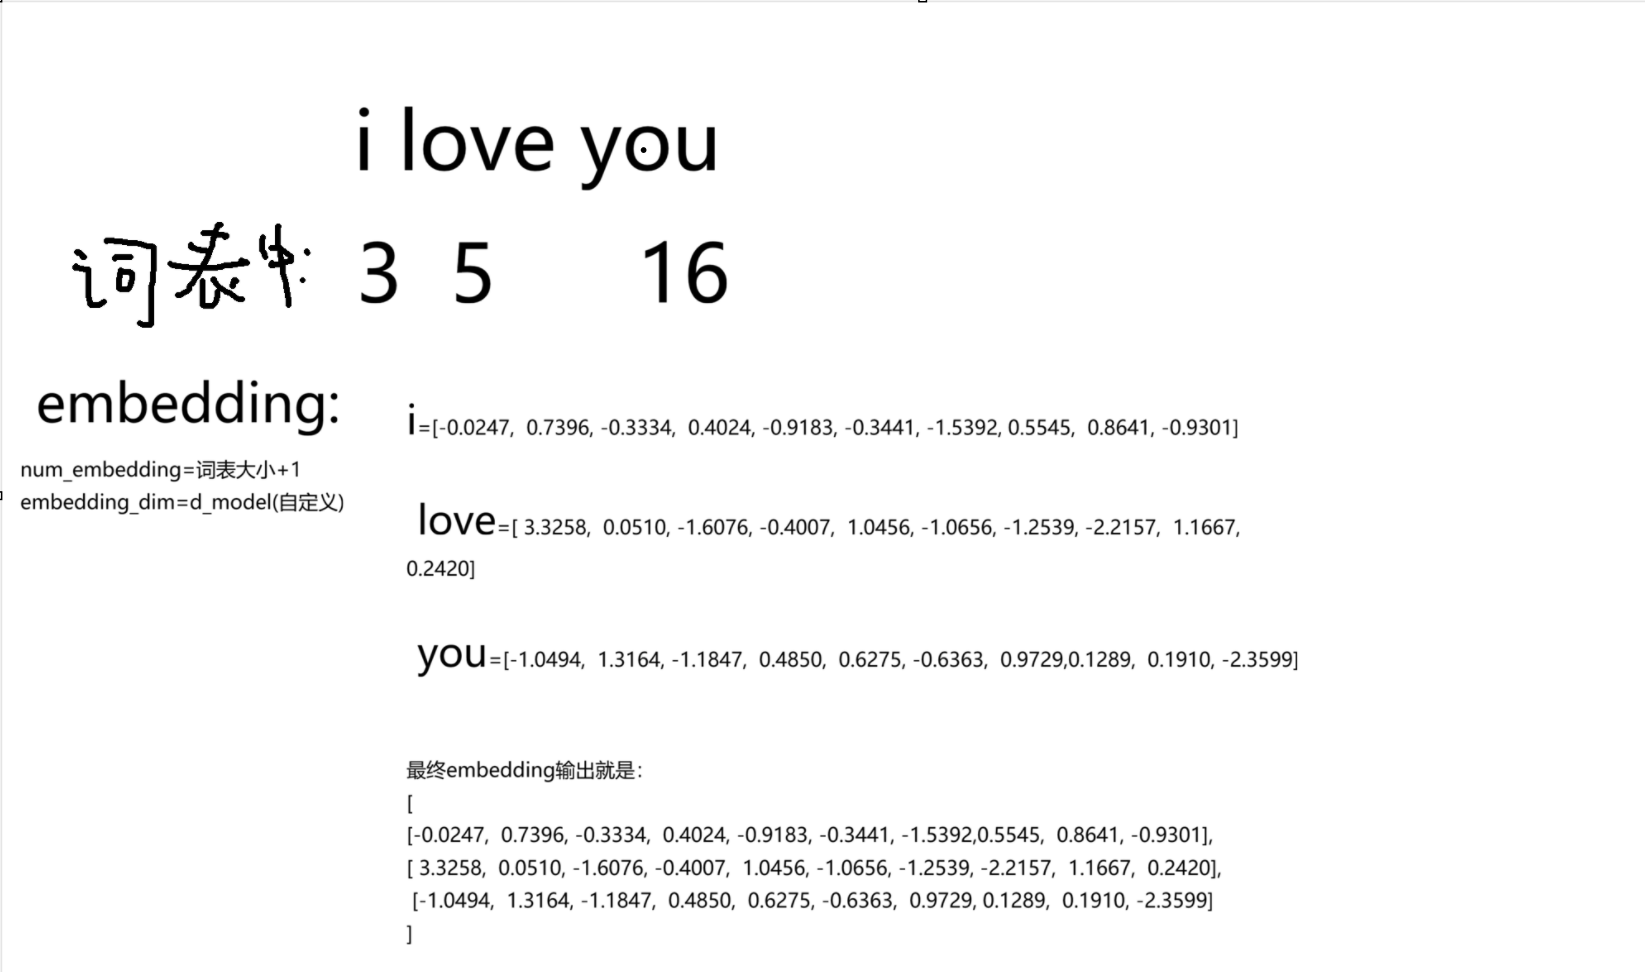

In [170]:
embedding=nn.Embedding(num_embeddings=vocab_size+1,embedding_dim=10) 
show_embedding=embedding(x)
show_embedding#这里可以看出第一个维度dim0是batch_size(此处为整个，没细分batch)，x真实shape是dim1、dim2


'''
维度问题：按流程
识别token后，input维度为（batch,len）,len指的是一句话中所有token翻译为词表中索引后的长度，也就是一句话中含的token数
对词表索引列表形式执行embedding后：维度变为（batch,len,embedding_dim） 将每一个词表索引重新由单个数设置为embedding层设置的embedding_dim=10，原来的一行输入会变成一个矩阵
'''
show_embedding

tensor([[[ 0.7573, -0.5338,  0.3984,  ..., -0.6097, -0.8522,  1.3015],
         [ 0.2190,  0.4862, -0.6781,  ...,  0.0175,  0.1045, -0.7385],
         [ 0.3440,  0.3238,  0.3249,  ...,  1.1478,  0.0450,  0.4883],
         ...,
         [ 2.4038, -3.1206,  1.3251,  ...,  0.2173,  0.8478, -0.0403],
         [-0.7687, -0.8647,  0.5714,  ...,  1.2404,  1.6950, -0.7938],
         [ 0.3539, -0.4450, -0.7195,  ...,  1.2262, -0.7066,  3.0066]],

        [[ 1.5912, -0.1183, -1.4507,  ..., -0.3043,  0.6208,  0.3461],
         [ 1.3037,  0.1458,  0.0482,  ..., -1.3571,  0.5483,  1.3457],
         [-0.2012, -0.7787,  1.3530,  ..., -0.3416,  0.3593, -0.0151],
         ...,
         [-0.1322, -0.3898,  0.9116,  ...,  0.4309, -1.0301,  2.5740],
         [ 0.9939,  0.4153, -1.7095,  ...,  0.3567,  0.0162,  0.3934],
         [ 0.3539, -0.4450, -0.7195,  ...,  1.2262, -0.7066,  3.0066]],

        [[-0.5969, -1.6358, -1.3241,  ...,  0.3116,  2.6042, -0.1576],
         [-0.3501, -0.1210,  1.6956,  ...,  0

In [171]:
#hyper parameters
d_model=512
d_k=64
d_v=64
num_heads=8
lr=1e-2
epochs=4000
device="cuda:0"

### 如果要使用casual musk:
### 在QK/sqrt(dk)运算之后，再按元素加一个矩阵，这个矩阵其中上半三角为"-∞" 这样可以使softmax的时候对应mask的位置概率为0，下半三角为0
不用乘法是因为-inf无法相乘
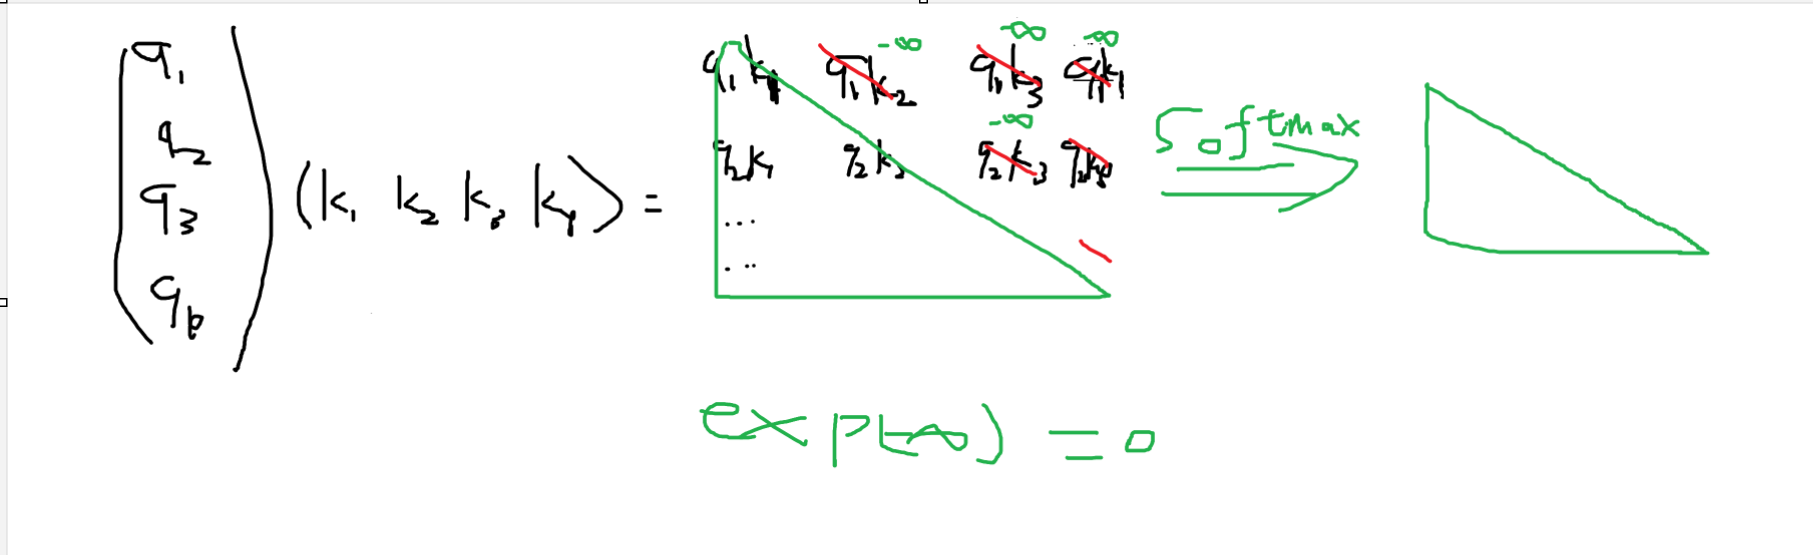

In [172]:
def Attention(Q,K,V):
#   alpha=torch.softmax((Q@K.transpose(-2,-1))/(d_k**0.5),dim=-1)#需要指定转置（qkv均为三维（含batch）），需要指定按行softmax
#加上casule mask:
    B,H,N,_=Q.shape
    mask=torch.tril(torch.ones(B,H,N,N))#tril生成下三角
    #再将所有0位置替换为布尔无穷小
    mask=mask.masked_fill(mask == 0, float('-inf'))
    #再将所有1替换为布尔0
    mask=mask.masked_fill(mask==1,0.0)
    mask=mask.to(Q.device)
    alpha=torch.softmax((Q@K.transpose(-2,-1))/(d_k**0.5)+mask,dim=-1)

    h=alpha@V
    return h

### 向量方法先得角度矩阵再偶数取sin，奇数取cos计算
循环实现的代码确实更贴近数学公式的逐字翻译，读起来像伪代码一样直观。而向量化版本需要理解广播、切片、对数变换等技巧，初次接触会觉得绕  
不过在实际工程中，向量化有两个循环无法替代的优势：  
#### 1.*性能差距巨大*  
当 max_len=5000、d_model=512 时，双层循环需要执行约 256 万次 Python 级别的迭代，而向量化版本只需要几次底层 C++ 运算。训练大模型时，每次前向都调用位置编码，累计的时间差异非常可观。  
#### 2.*可维护性与灵活性*  
向量化代码一旦写好，修改参数（如 base、d_model）不需要调整循环逻辑。而循环代码如果要支持动态 max_len 或不同的 d_model，需要小心边界条件

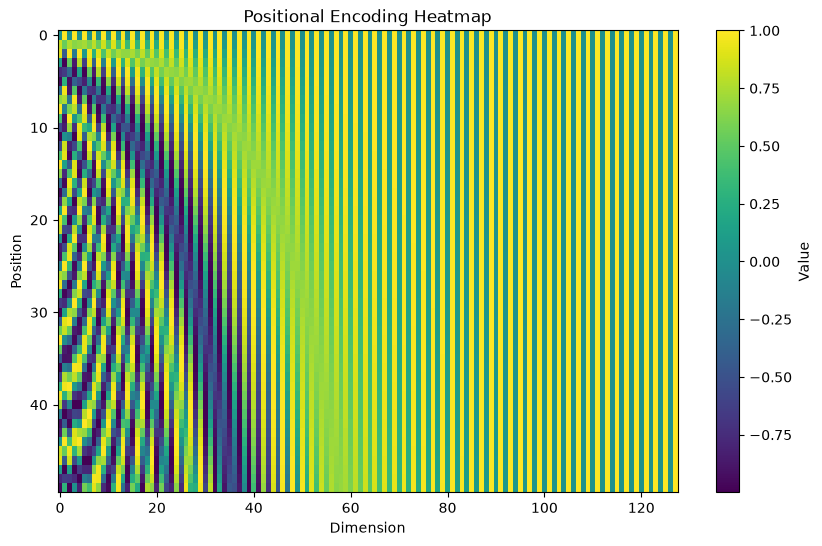

In [173]:
import math
class PositionalEmbed(nn.Module):
    def __init__(self,d_model,pos,base=10000,dropout=0.1):#embedding 后的x维度恰好是d_model，pos为序列最大长度（也就是每句tokens长度）
        super().__init__()
        self.dropout=nn.Dropout(p=dropout)#Dropout模块
        
        #position向量：
        p=torch.arange(0,pos,dtype=torch.float) #保证是float向量
        
        #角度向量:先生成等差的指数部分，再整体exp，否则无法直接生成
        #angle=torch.arange(0,-0.5*math.log(base),-2/d_model*math.log(base))
        factor=torch.arange(0,(d_model+1)//2,dtype=torch.float)
        factor=(-2/d_model*math.log(base))*factor
        factor=torch.exp(factor)

        angle=torch.matmul(p.unsqueeze(1),factor.unsqueeze(0))#torch的一维向量没有行列概念，所有一维向量相乘都只有内积，所以需要使用unsqueeze函数
        #（pos,）是一维，pytorch中一维向量没有行列之分，（pos,1）就是二维了（列矩阵）
        #matmul对一维向量执行点积，对二维向量执行矩阵乘法
        #可以使用 .reshape(pos, 1) 或 .view(pos, 1) 将一维张量 (pos,) 转换为二维列向量 (pos, 1)。这两种方法与 .unsqueeze(1) 的效果等价，都是增加一个维度。
        
        pe=torch.zeros(pos,d_model)
        pe[:,0::2]=torch.sin(angle)#0::2表示从0开始每隔两个取一个    #对整个e做出预修改然后取用
        if d_model % 2 == 0:
            pe[:, 1::2] = torch.cos(angle)
        else:
            pe[:, 1::2] = torch.cos(angle[:, :d_model//2]) 

        self.register_buffer('pe',pe)#将init中的局部变量e变为全局

        
    def forward(self,x):#forward函数负责将计算好的位置编码加到embedding(x)上,
                          #因为nn.Module机制规定只有forward函数里的操作才能参与反向传播，追踪梯度
        x=x+self.pe[:x.size(1)]#为了追踪这个加法的梯度
        x=self.dropout(x)
        return x   





#可视化
import matplotlib.pyplot as plt

# 假设你已经实例化了 PositionalEmbed
pos_embed = PositionalEmbed(d_model=128, pos=50)  # 小维度便于观察
pe = pos_embed.pe.cpu().numpy()

plt.figure(figsize=(10, 6))
plt.imshow(pe, aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.xlabel('Dimension')
plt.ylabel('Position')
plt.title('Positional Encoding Heatmap')
plt.show()
        

## 多头注意力
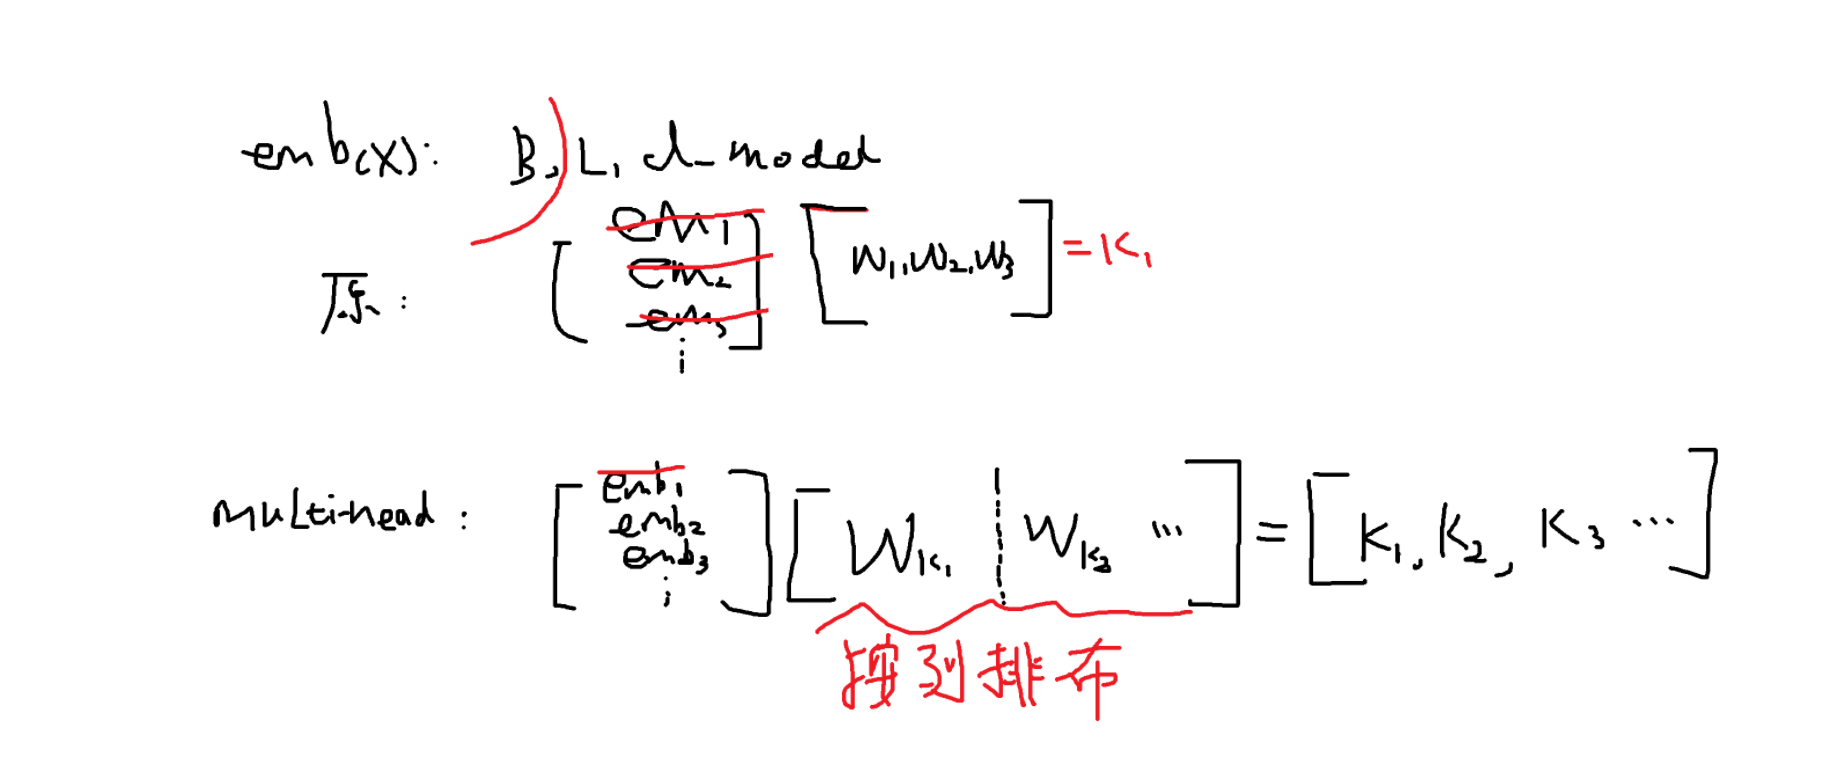
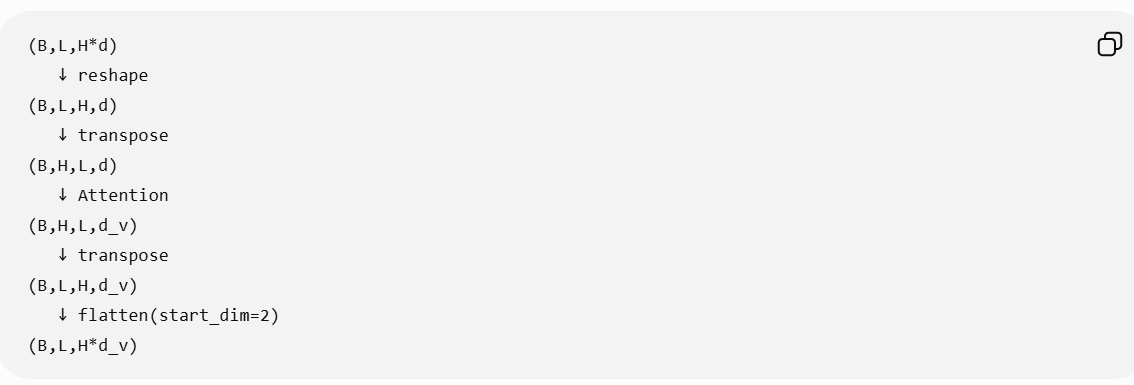

## 对两个 4D 张量（比如 (B, H, L, d_k)）进行矩阵乘法时，PyTorch 会把前面的维度 (B, H) 看作是“批次”，然后在这个“批次”里的每一个“小矩阵” (L, d_k) 上独立地执行矩阵乘法。这个机制在技术上被称为 广播（Broadcasting） 和 批处理矩阵乘法（Batched Matrix Multiplication）。

In [174]:
_,pos=x.shape        
pos#每句tokens长度 
    

class TextGen(nn.Module):
    def __init__(self,vocab_size,d_model,d_k,d_v):
        super().__init__()
        #embedding层在对照单词表将每一个token转换为一个d_model维度的向量，向量内容会在训练中更新
        self.embedding=nn.Embedding(num_embeddings=vocab_size+1,embedding_dim=d_model)  
        #xshape:(Batch,Len_tokens,embed_dim(d_model))
        self.positionembed=PositionalEmbed(d_model=d_model,pos=pos)

        #多头注意力：[W1|W2|W3|W4|...]
        self.w_q=nn.Linear(d_model,d_k*num_heads) 
        self.w_k=nn.Linear(d_model,d_k*num_heads)
        self.w_v=nn.Linear(d_model,d_v*num_heads)  
        self.w0=nn.Linear(d_v*num_heads,d_model)
        self.output_proj=nn.Linear(d_model,vocab_size+1)#将最后的输出映射回词表大小！！！！！！！！！！！！
        #理解这个设计哲学：也可以将d_v本身设置为vocab_size+1
    
    
    def forward(self,x):
        x=self.embedding(x)
        x=self.positionembed(x)
        Q=self.w_q(x)
        K=self.w_k(x)
        V=self.w_v(x)
        #先计算后拆分
        Bq,Lq,numxKq=Q.shape#K与Q形状完全一致
        #print("Q:",Q.shape,"Bq:",Bq)
        Bv,Lv,numxKv=V.shape
        Q=Q.reshape(Bq,Lq,num_heads,numxKq//num_heads)#reshape都是重排元素，所以只能拆为相邻元素
        K=K.reshape(Bq,Lq,num_heads,numxKq//num_heads)
        V=V.reshape(Bv,Lv,num_heads,numxKv//num_heads)
        Q = Q.transpose(1, 2)  # (B, L,num_heads, d_k) -> (B, num_heads, L, d_k)   转置第1，2维度
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)
        h_fin = Attention(Q, K, V)  # 输出 (B, Heads, L, d_v)
        h_fin = h_fin.transpose(1,2)  # (B, L, H, d_v)
        h_fin=h_fin.flatten(start_dim=2)  #(B,L,H*d_v)
        h_fin=self.w0(h_fin)

       # print("h_fin shape",h_fin.shape)    #15 4 512
       # last_h = h_fin[:, -1, :] 
       # print("last_h:",last_h.shape)   #15 512
        logits = self.output_proj(h_fin)
       # print("final logits shape",logits.shape) #15 4 72
        return logits



model=TextGen(vocab_size,d_model,d_k,d_v)
model=model.to(device)


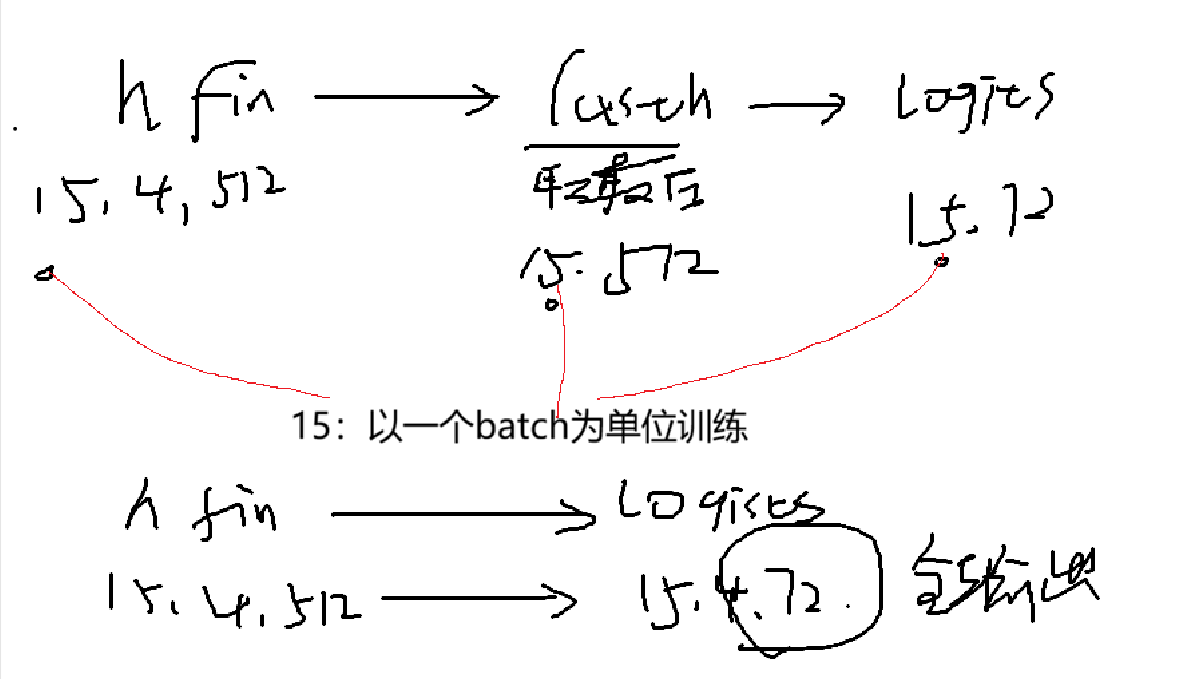

In [175]:
#数据准备
x_train=x[:,:-1]
y_train=x[:,1:]
print("x_train shape:", x_train.shape)  # (5 最大长度)
print("y_train shape:", y_train.shape)


x_train shape: torch.Size([20, 14])
y_train shape: torch.Size([20, 14])


In [177]:
# 假设你已经有了这些：
# model: 你的模型
# x_train: (4, 2) 整数 token ID
# y_train: (4, 2) 整数 token ID

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

for epoch in tqdm(range(epochs)):
    x_train=x_train.to(device)
    y_train=y_train.to(device)
    # 1. 前向传播：输入整数ID，输出每个位置对每个词的得分
    y_pred = model(x_train)
    y_pred=y_pred.transpose(1,2)   #!!!!类别数72要在4之前
    y_train=y_train.squeeze(-1)   #squeeze是消除维度，unsqueeze则是增加维度（都无法凭空增减）
   
   # print("y_train shape",y_train.shape)   #15 4 1
   # print("y_pred shape",y_pred.shape)   #15 72，4
    loss=criterion(y_pred, y_train) 
    
    
    # 3. 反向传播 + 更新参数
    optimizer.zero_grad()   # 清空上一步的梯度
    loss.backward()         # 计算梯度
    optimizer.step()        # 更新参数
    
    if (epoch + 1) % 1000 == 0:
        print(f"epoch {epoch+1}, loss: {loss.item():.4f}")

 26%|██▌       | 1020/4000 [00:05<00:14, 206.24it/s]

epoch 1000, loss: 7.6488


 51%|█████     | 2028/4000 [00:10<00:09, 202.52it/s]

epoch 2000, loss: 19.3761


 76%|███████▌  | 3025/4000 [00:15<00:04, 206.18it/s]

epoch 3000, loss: 3.6624


100%|██████████| 4000/4000 [00:19<00:00, 201.06it/s]

epoch 4000, loss: 23.2638


In [ ]:
torch.save(model.state_dict(),"toymodel.param")  #新版本state_dict()后面必须加()
test_model=TextGen(vocab_size,d_model,d_k,d_v)
test_model.load_state_dict(torch.load("toymodel.param"))
test_model.eval()
while 1:
    string = input("输入多个词").split()

    indices = [vocab.get(word, vocab.get('<unk>', 0)) for word in string]
    test_input = torch.tensor([indices])
    logits = test_model(test_input)  # shape: (1, len_input, vocab_size)

    # 对每个时间步取 argmax，得到预测的词索引序列
    pred_indices = logits.argmax(dim=-1)[0].tolist()  # shape: (len_input,)

    # 把预测的索引转回词
    idx2word = {idx: word for word, idx in vocab.items()}

    pred_words = [idx2word[idx] for idx in pred_indices]

    print("输入: ", string)
    print("模型预测的下一个词:", pred_words)

输入多个词 千 里 送 归 舟


输入:  ['千', '里', '送', '归', '舟']
模型预测的下一个词: ['里', '送', '未', '未', '月']


输入多个词 未 月 


输入:  ['未', '月']
模型预测的下一个词: ['灭', '灭']
